# Titanic Survival Modeling Pipeline

**Competition:** Kaggle - Titanic: Machine Learning from Disaster  
**Purpose:** Keep a focused, reproducible modeling workflow for preprocessing, feature engineering, validation, and submission generation.

Exploratory analysis is documented separately in `EDA.ipynb`.


## 1. Environment Setup

Import required libraries, set the random seed, and define shared project paths.


In [5045]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization (optional for later EDA)
import matplotlib.pyplot as plt

# Machine Learning
from sklearn.model_selection import cross_val_score   
from sklearn.ensemble import GradientBoostingClassifier


# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

DATA_PATH = "../data/"


## 2. Data Loading

Load the train/test datasets and sample submission template used by the modeling pipeline.


In [5046]:
train_df = pd.read_csv(DATA_PATH + "train.csv")
test_df = pd.read_csv(DATA_PATH + "test.csv")
sample_submission = pd.read_csv(DATA_PATH + "gender_submission.csv")

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)
print("Sample submission shape:", sample_submission.shape)

Train shape: (891, 12)
Test shape: (418, 11)
Sample submission shape: (418, 2)


## 3. Encoding, Preprocessing and Feature Engineering

Apply feature creation and missing-value handling steps before model-ready encoding.


In [5047]:
for df in [train_df, test_df]:
    df["FamilySize"] = df["SibSp"] + df["Parch"] + 1

In [5048]:
for df in [train_df, test_df]:
    df["Title"] = df["Name"].str.extract(r" ([A-Za-z]+)\.", expand=False)
    df["Title"] = df["Title"].replace(['Dr', 'Rev', 'Major', 'Col', 'Don', 'Sir', 'Capt', 'Jonkheer'], 'Mr')
    df["Title"] = df["Title"].replace(['Mlle', 'Ms'], 'Miss')
    df["Title"] = df["Title"].replace(['Mme', 'Lady', 'Countess', 'Dona'], 'Mrs')
    df["HasCabin"] = df["Cabin"].notna().astype(int)
    

In [5049]:
for df in [train_df, test_df]:
    df["Age"] = df.groupby("Title")["Age"].transform( lambda x: x.fillna(x.median()))
test_df["Fare"] = test_df["Fare"].fillna(test_df["Fare"].median())
train_df["Embarked"] = train_df["Embarked"].fillna(train_df["Embarked"].mode()[0])

In [5050]:
passenger_id = test_df["PassengerId"]



for df in [train_df, test_df]:
    df["Sex"] = df["Sex"].map({"male": 0, "female": 1})
    df["Embarked"] = df["Embarked"].fillna("S")
    df["Embarked"] = df["Embarked"].map({"S": 0, "C": 1, "Q": 2})
    df["Title"] = df["Title"].map({"Mr": 0, "Miss": 1, "Mrs": 2, "Master": 3}).fillna(0).astype(int)

    df["Fare_Per_Person"] = df["Fare"] / df["FamilySize"]
    df['FareLog']             = np.log1p(df['Fare'])          
    df['Fare_Per_Person_Log'] = np.log1p(df['Fare_Per_Person'])
    df['Age_Class']           = df['Age'] * df['Pclass']       
    df['Sex_x_Pclass']        = df['Sex'] * df['Pclass']       
    df['Age_Sex']             = df['Age'] * df['Sex']          
    df['Sex_Title']           = df['Sex'] * df['Title']        
    df['IsWoman_1st']         = ((df['Sex']==0) & (df['Pclass']==1)).astype(int)
    df['IsWoman_3st']         = ((df['Sex']==0) & (df['Pclass']==3)).astype(int)
    df['IsWoman']             = ((df['Sex']==0)).astype(int)
    df['IsBoy']               = ((df['Age']<15) & (df['Sex']==1)).astype(int)
    df['IsBoyAlone']     = ((df['Age'] < 15) & (df['FamilySize'] == 1)).astype(int)
    
    df.drop(["Name", "Ticket", "Cabin", "Parch", "SibSp", "PassengerId", "Fare", "Fare_Per_Person", "FamilySize"], axis=1, inplace=True)
    
train_df.head()

,Survived,Pclass,Sex,Age,Embarked,Title,HasCabin,FareLog,Fare_Per_Person_Log,Age_Class,Sex_x_Pclass,Age_Sex,Sex_Title,IsWoman_1st,IsWoman_3st,IsWoman,IsBoy,IsBoyAlone
0,0,3,0,22.0,0,0,0,2.110213,1.531476,66.0,0,0.0,0,0,1,1,0,0
1,1,1,1,38.0,1,2,1,4.280593,3.601186,38.0,1,38.0,2,0,0,0,0,0
2,1,3,1,26.0,0,1,0,2.188856,2.188856,78.0,3,26.0,1,0,0,0,0,0
3,1,1,1,35.0,0,2,1,3.990834,3.316003,35.0,1,35.0,2,0,0,0,0,0
4,0,3,0,35.0,0,0,0,2.202765,2.202765,105.0,0,0.0,0,0,1,1,0,0


## 4. Dataset Assembly, and Cross-Validation

build training/testing matrices, initialize the model, and estimate accuracy with cross-validation.

In [5051]:
y_train = train_df["Survived"]
X_train = train_df.drop("Survived", axis=1)
X_test = test_df

model = GradientBoostingClassifier(
    n_estimators    = 200, 
    learning_rate   = 0.01,
    max_depth       = 3,
    max_features    = 'sqrt',
    random_state    = 42
)

scores = cross_val_score(model, X_train, y_train, cv=5, scoring="accuracy")
print("Mean CV accuracy:", scores.mean())


Mean CV accuracy: 0.8125792480070302


## 5. Final Training and Submission Export

Fit the model on the full training set, predict on the test set, and save the submission file.


In [5052]:
model.fit(X_train, y_train)
preds = model.predict(X_test)

submission = pd.DataFrame({
    "PassengerId": passenger_id,
    "Survived": preds
})

submission.to_csv("../output/submissions/submission.csv", index=False)
print("Submission saved to:", "../output/submissions/submission.csv")

submission.head()

Submission saved to: ../output/submissions/submission.csv


,PassengerId,Survived
0,892,0
1,893,0
2,894,0
3,895,0
4,896,0


## 6. Prediction Distribution Check

Plot the predicted class balance as a final post-training sanity check.


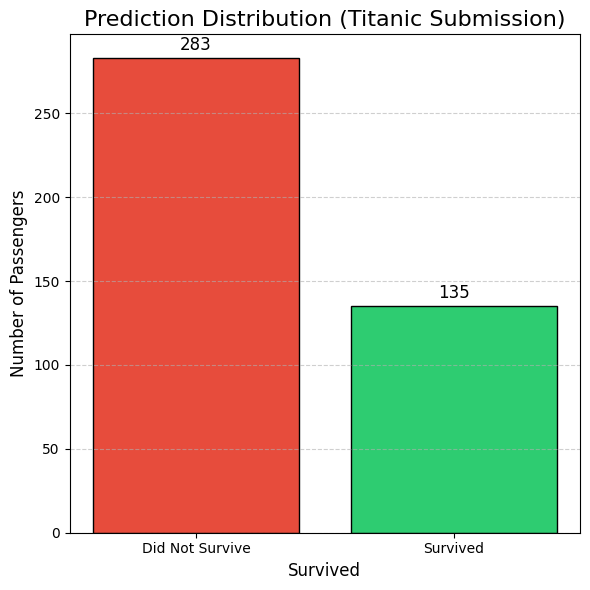

In [ ]:
plt.figure(figsize=(6,6))

counts = submission["Survived"].value_counts()

plt.bar(
    counts.index,
    counts.values,
    color=["#e74c3c", "#2ecc71"],
    edgecolor="black"
)

plt.title("Prediction Distribution (Titanic Submission)", fontsize=16)
plt.xlabel("Survived", fontsize=12)
plt.ylabel("Number of Passengers", fontsize=12)

plt.xticks([0,1], ["Did Not Survive", "Survived"])

for i, v in enumerate(counts.values):
    plt.text(i, v + 5, str(v), ha='center', fontsize=12)

plt.grid(axis="y", linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()